In [2]:
!pip install pandas
!pip install numpy


In [91]:

import pandas as pd
df = pd.read_excel('Obs.xls', engine='xlrd')
df.head()

,Age,DiabetesYes1,Rheumatological,Respiratorydiseases,Hypertension,Hypothyroidism,Cardiovasculardiseases,cerebrovasculardiseases,Renaldiseases,others_disease,...,PostOperative_Case,Emergency_Surgery,Diagnosis_Disease,Ventilated_Mechanical,Sedation_admission,Cardiovascular_Support,Vasoactiveterapy,Use_antibiotic,Replacement_Renal,Mortality_Status
0,30,0,0,0,0,0,0,0,0,0,...,0,0,5,1,0.0,0.0,0.0,0.0,0.0,1
1,26,0,0,0,0,0,0,0,0,0,...,1,1,3,1,0.0,0.0,0.0,1.0,0.0,1
2,33,0,0,0,0,0,0,0,0,0,...,0,0,8,0,0.0,1.0,1.0,1.0,0.0,1
3,25,0,0,0,0,0,0,0,0,0,...,0,0,5,0,1.0,0.0,0.0,1.0,0.0,1
4,30,0,0,0,0,0,0,0,0,0,...,1,1,3,0,1.0,1.0,1.0,1.0,0.0,0


# Data Cleaning

In [92]:
# Check whether the data is null or not
df.isnull().sum()

,0
Age,0
DiabetesYes1,0
Rheumatological,0
Respiratorydiseases,0
Hypertension,0
Hypothyroidism,0
Cardiovasculardiseases,0
cerebrovasculardiseases,0
Renaldiseases,0
others_disease,0


In [93]:
# Treatment of null values
null_columns = [
    'Pa02', 'PEEP', 'ArterialPH', 'systolic_blood_pressure',
    'diastolic_blood_pressure', 'respiratory_rate', 'heart_rate',
    'Temperature', 'blood_sugar_level', 'hemoglobin', 'platelets',
    'WBC', 'Serum_sodium', 'serum_potassium', 'serum_bicarbonate',
    'serum_creatinine', 'serum_bilirubin', 'blood_urea'
]

# Fill with mean
for col in null_columns:
    df[col] = df[col].fillna(df[col].mean())

# Verify all zeros
print(df[null_columns].isnull().sum())

Pa02                        0
PEEP                        0
ArterialPH                  0
systolic_blood_pressure     0
diastolic_blood_pressure    0
respiratory_rate            0
heart_rate                  0
Temperature                 0
blood_sugar_level           0
hemoglobin                  0
platelets                   0
WBC                         0
Serum_sodium                0
serum_potassium             0
serum_bicarbonate           0
serum_creatinine            0
serum_bilirubin             0
blood_urea                  0
dtype: int64


In [94]:
# Fill catagorical null values with 0.
categorical_columns = [
    'Sedation_admission', 'Cardiovascular_Support',
    'Vasoactiveterapy', 'Use_antibiotic', 'Replacement_Renal'
]

# Fill with 0
df[categorical_columns] = df[categorical_columns].fillna(0)

# Verify
print(df[categorical_columns].isnull().sum())

Sedation_admission        0
Cardiovascular_Support    0
Vasoactiveterapy          0
Use_antibiotic            0
Replacement_Renal         0
dtype: int64


In [95]:
df.isnull().sum()

,0
Age,0
DiabetesYes1,0
Rheumatological,0
Respiratorydiseases,0
Hypertension,0
Hypothyroidism,0
Cardiovasculardiseases,0
cerebrovasculardiseases,0
Renaldiseases,0
others_disease,0


In [96]:
# Check data types
df.dtypes

,0
Age,int64
DiabetesYes1,int64
Rheumatological,int64
Respiratorydiseases,int64
Hypertension,int64
Hypothyroidism,int64
Cardiovasculardiseases,int64
cerebrovasculardiseases,int64
Renaldiseases,int64
others_disease,int64


In [97]:
# check whether the data is duplicate or not
df.duplicated().sum()

np.int64(0)

In [98]:
df.shape
df.size

10794

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       257 non-null    int64  
 1   DiabetesYes1              257 non-null    bool   
 2   Rheumatological           257 non-null    bool   
 3   Respiratorydiseases       257 non-null    bool   
 4   Hypertension              257 non-null    bool   
 5   Hypothyroidism            257 non-null    bool   
 6   Cardiovasculardiseases    257 non-null    bool   
 7   cerebrovasculardiseases   257 non-null    bool   
 8   Renaldiseases             257 non-null    bool   
 9   others_disease            257 non-null    bool   
 10  Fio2                      257 non-null    float64
 11  Pa02                      257 non-null    float64
 12  PEEP                      257 non-null    float64
 13  ArterialPH                257 non-null    float64
 14  systolic_b

In [99]:
df.describe()

,Age,DiabetesYes1,Rheumatological,Respiratorydiseases,Hypertension,Hypothyroidism,Cardiovasculardiseases,cerebrovasculardiseases,Renaldiseases,others_disease,...,PostOperative_Case,Emergency_Surgery,Diagnosis_Disease,Ventilated_Mechanical,Sedation_admission,Cardiovascular_Support,Vasoactiveterapy,Use_antibiotic,Replacement_Renal,Mortality_Status
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,...,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000
mean,28.634241,0.007782,0.023346,0.023346,0.058366,0.116732,0.058366,0.011673,0.007782,0.042802,...,0.762646,0.653696,3.128405,0.700389,0.171206,0.178988,0.178988,0.883268,0.023346,0.945525
std,5.787790,0.088044,0.151295,0.151295,0.234891,0.321727,0.234891,0.107619,0.088044,0.202804,...,0.426291,0.476720,1.572173,0.458981,0.377424,0.384091,0.384091,0.321727,0.151295,0.227395
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,4.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,49.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [100]:
df

,Age,DiabetesYes1,Rheumatological,Respiratorydiseases,Hypertension,Hypothyroidism,Cardiovasculardiseases,cerebrovasculardiseases,Renaldiseases,others_disease,...,PostOperative_Case,Emergency_Surgery,Diagnosis_Disease,Ventilated_Mechanical,Sedation_admission,Cardiovascular_Support,Vasoactiveterapy,Use_antibiotic,Replacement_Renal,Mortality_Status
0,30,0,0,0,0,0,0,0,0,0,...,0,0,5,1,0.0,0.0,0.0,0.0,0.0,1
1,26,0,0,0,0,0,0,0,0,0,...,1,1,3,1,0.0,0.0,0.0,1.0,0.0,1
2,33,0,0,0,0,0,0,0,0,0,...,0,0,8,0,0.0,1.0,1.0,1.0,0.0,1
3,25,0,0,0,0,0,0,0,0,0,...,0,0,5,0,1.0,0.0,0.0,1.0,0.0,1
4,30,0,0,0,0,0,0,0,0,0,...,1,1,3,0,1.0,1.0,1.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,30,0,0,0,0,0,0,0,0,0,...,1,1,2,1,0.0,0.0,0.0,1.0,0.0,1
253,30,0,0,0,0,0,0,0,0,0,...,1,0,2,1,0.0,0.0,0.0,1.0,0.0,1
254,24,0,0,0,0,1,0,0,0,0,...,1,1,2,1,0.0,0.0,0.0,1.0,0.0,1
255,28,0,0,0,0,0,1,0,0,0,...,1,1,2,1,0.0,0.0,0.0,1.0,0.0,1


In [101]:
# change data types
df_convert = ['DiabetesYes1', 'Rheumatological', 'Respiratorydiseases',
              'Hypertension', 'Hypothyroidism', 'Cardiovasculardiseases', 'cerebrovasculardiseases',
              'Renaldiseases', 'others_disease', 'PostOperative_Case', 'Emergency_Surgery',
              'Ventilated_Mechanical', 'Sedation_admission', 'Cardiovascular_Support', 'Vasoactiveterapy',
             'Use_antibiotic', 'Replacement_Renal', 'Mortality_Status']
df[df_convert] = df[df_convert].astype(bool)
df.dtypes

,0
Age,int64
DiabetesYes1,bool
Rheumatological,bool
Respiratorydiseases,bool
Hypertension,bool
Hypothyroidism,bool
Cardiovasculardiseases,bool
cerebrovasculardiseases,bool
Renaldiseases,bool
others_disease,bool


In [102]:
df[df_convert] = df[df_convert].astype(int)
for col in df_convert:
    df[col] = df[col].map({0: 'No', 1: 'Yes'})

print(df[df_convert].head())

  DiabetesYes1 Rheumatological Respiratorydiseases Hypertension  \
0           No              No                  No           No   
1           No              No                  No           No   
2           No              No                  No           No   
3           No              No                  No           No   
4           No              No                  No           No   

  Hypothyroidism Cardiovasculardiseases cerebrovasculardiseases Renaldiseases  \
0             No                     No                      No            No   
1             No                     No                      No            No   
2             No                     No                      No            No   
3             No                     No                      No            No   
4             No                     No                      No            No   

  others_disease PostOperative_Case Emergency_Surgery Ventilated_Mechanical  \
0             No               

In [103]:
int_columns = ['PEEP', 'systolic_blood_pressure', 'diastolic_blood_pressure',
               'respiratory_rate', 'heart_rate', 'blood_sugar_level',
               'platelets', 'WBC']

df[int_columns] = df[int_columns].astype(int)

print(df[int_columns].dtypes)

PEEP                        int64
systolic_blood_pressure     int64
diastolic_blood_pressure    int64
respiratory_rate            int64
heart_rate                  int64
blood_sugar_level           int64
platelets                   int64
WBC                         int64
dtype: object


In [104]:
# Conversion of Admission source in catagorical variables
df['Admission_Source'] = df['Admission_Source'].map({
    1: 'ED – same hospital',
    2: 'ICU/HDU – other hospital',
    3: 'ICU/HDU – same hospital',
    4: 'Operating theatre',
    5: 'Operating theatre - same hospital',
    6: 'Ward – other hospital',
    7: 'Ward – same hospital'
})

# Verify
print(df['Admission_Source'].value_counts())

Admission_Source
Operating theatre - same hospital    116
Ward – same hospital                  61
ED – same hospital                    58
ICU/HDU – same hospital               16
Ward – other hospital                  3
ICU/HDU – other hospital               2
Operating theatre                      1
Name: count, dtype: int64


In [105]:
# Conversion of diagnosis disease into catagorical
df['Diagnosis_Disease'] = df['Diagnosis_Disease'].map({
    1: 'Ectopic Pregnancy',
    2: 'Elective LSCS',
    3: 'Emergency LSCS',
    4: 'Hemorrhage (Antepartum + Postpartum)',
    5: 'Hypertensive disorders (Pre-eclampsia, postpartum-eclampsia, HELLP)',
    6: 'Miscarriage & Abortion',
    7: 'Postpartum Conditions (Trauma/Surgical/Other)',
    8: 'Pregnancy-Related Complications (Non-hypertensive)'
})

# Verify
print(df['Diagnosis_Disease'].value_counts())

Diagnosis_Disease
Elective LSCS                                                          117
Emergency LSCS                                                          60
Hypertensive disorders (Pre-eclampsia, postpartum-eclampsia, HELLP)     41
Hemorrhage (Antepartum + Postpartum)                                    11
Ectopic Pregnancy                                                        9
Miscarriage & Abortion                                                   7
Pregnancy-Related Complications (Non-hypertensive)                       6
Postpartum Conditions (Trauma/Surgical/Other)                            6
Name: count, dtype: int64


In [106]:
# Checking all data
df.head()
df.info()
df.dtypes
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       257 non-null    int64  
 1   DiabetesYes1              257 non-null    object 
 2   Rheumatological           257 non-null    object 
 3   Respiratorydiseases       257 non-null    object 
 4   Hypertension              257 non-null    object 
 5   Hypothyroidism            257 non-null    object 
 6   Cardiovasculardiseases    257 non-null    object 
 7   cerebrovasculardiseases   257 non-null    object 
 8   Renaldiseases             257 non-null    object 
 9   others_disease            257 non-null    object 
 10  Fio2                      257 non-null    float64
 11  Pa02                      257 non-null    float64
 12  PEEP                      257 non-null    int64  
 13  ArterialPH                257 non-null    float64
 14  systolic_b

np.int64(0)

In [107]:
# Save the data
df.to_excel('clean data.xlsx', index = False)
print('Saved successfully!')

Saved successfully!


 # Data visualization through seaborn

In [108]:
import pandas as pd
data = pd.read_excel(r'/content/clean_data_python.xlsx')

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_new = data
data_new.sample(10)


,Age,DiabetesYes1,Rheumatological,Respiratorydiseases,Hypertension,Hypothyroidism,Cardiovasculardiseases,cerebrovasculardiseases,Renaldiseases,others_disease,...,PostOperative_Case,Emergency_Surgery,Diagnosis_Disease,Ventilated_Mechanical,Sedation_admission,Cardiovascular_Support,Vasoactiveterapy,Use_antibiotic,Replacement_Renal,Mortality_Status
99,25,No,No,No,No,No,No,No,No,No,...,Yes,No,Elective LSCS,Yes,No,No,No,Yes,No,Yes
240,29,No,No,No,No,No,No,No,No,No,...,No,No,"Hypertensive disorders (Pre-eclampsia, postpar...",Yes,Yes,No,No,Yes,No,Yes
200,25,No,Yes,No,No,No,No,No,No,No,...,Yes,Yes,Elective LSCS,Yes,No,Yes,Yes,Yes,No,Yes
40,34,No,No,No,No,No,No,No,No,No,...,No,No,Ectopic Pregnancy,Yes,No,No,No,Yes,No,Yes
199,29,No,No,No,No,No,No,No,No,No,...,Yes,Yes,Elective LSCS,Yes,No,No,No,Yes,No,Yes
231,24,No,No,No,No,Yes,No,No,Yes,Yes,...,Yes,Yes,Elective LSCS,Yes,Yes,Yes,Yes,Yes,Yes,Yes
20,22,No,No,No,No,No,No,No,No,No,...,No,No,"Hypertensive disorders (Pre-eclampsia, postpar...",Yes,Yes,Yes,Yes,Yes,Yes,Yes
212,38,No,No,No,No,No,No,No,No,No,...,Yes,No,Elective LSCS,No,No,Yes,Yes,Yes,No,Yes
79,30,No,No,No,No,No,No,No,No,No,...,Yes,Yes,Emergency LSCS,No,Yes,No,No,Yes,No,Yes
193,34,No,No,No,No,No,No,No,No,No,...,Yes,No,Elective LSCS,Yes,No,No,No,Yes,No,Yes


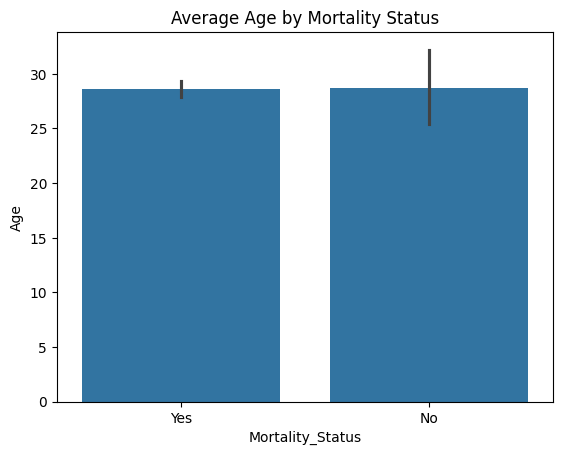

In [7]:
# Bar plot
fig, ax = plt.subplots()

sns.barplot(data=data, x='Mortality_Status', y='Age', ax=ax)

ax.set_title('Average Age by Mortality Status')
plt.show()

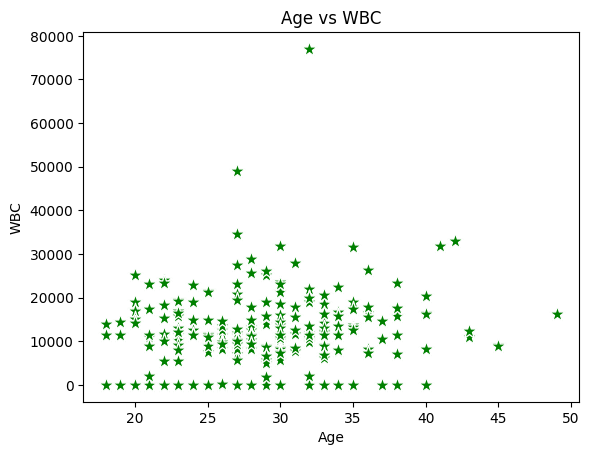

In [8]:
# Scatter Plot
fig, ax = plt.subplots()

sns.scatterplot(data=data, x='Age', y='WBC', ax=ax, color ="green", marker = "*", s = 140)

ax.set_title('Age vs WBC')
plt.show()

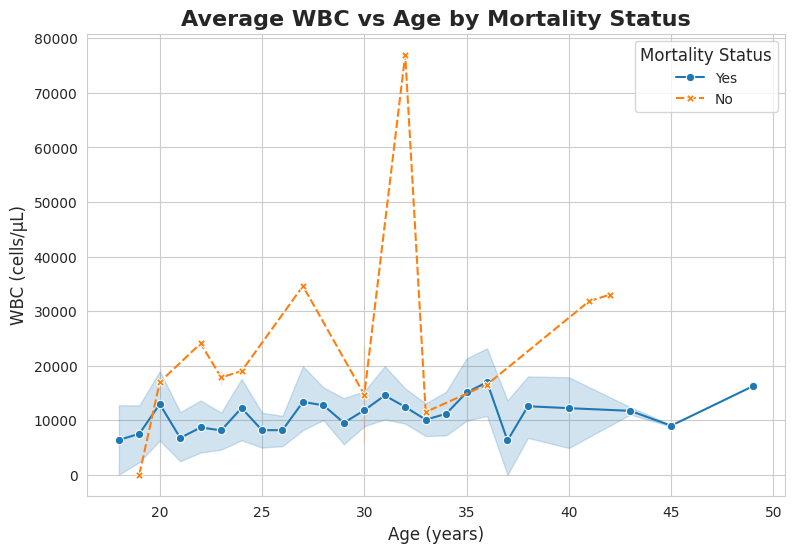

In [9]:
# Line plot
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plot
sns.set_style("whitegrid")

# Create figure and axes
fig, ax = plt.subplots(figsize=(9,6))

# Line plot with markers and custom line styles
sns.lineplot(
    x='Age',
    y='WBC',
    data=data,
    hue='Mortality_Status',
    style='Mortality_Status',
    markers=True,
    estimator='mean',
    ax=ax
)

# Titles and labels
ax.set_title('Average WBC vs Age by Mortality Status', fontsize=16, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('WBC (cells/µL)', fontsize=12)

# Legend formatting
ax.legend(title='Mortality Status', fontsize=10, title_fontsize=12)

# Show plot
plt.show()


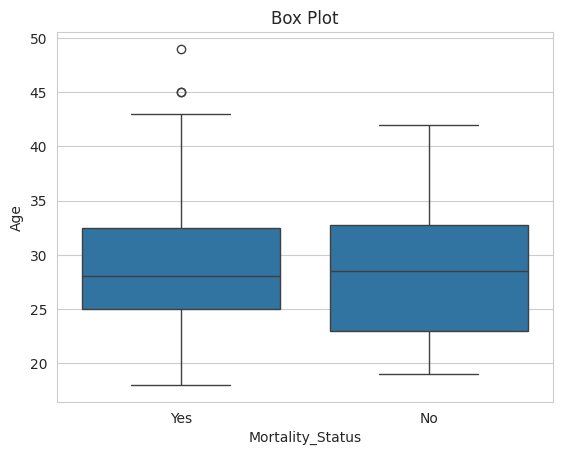

In [10]:
# Box plot
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sns.boxplot(x='Mortality_Status', y='Age', ax = ax, data = data)
ax.set_title ('Box Plot')
plt.show()


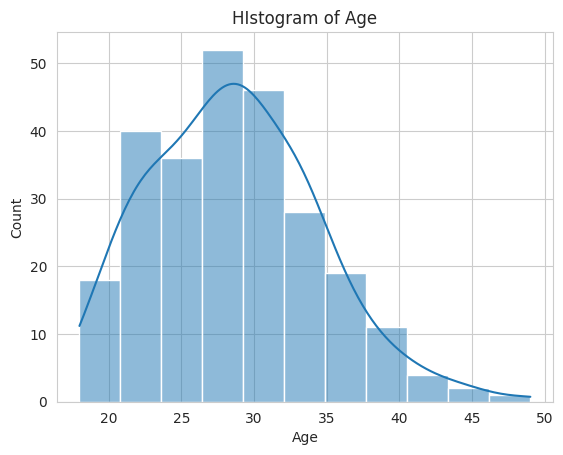

In [11]:
# Histogram
fig, ax = plt.subplots()
bin_size = round(len(data)**0.5)

sns.histplot(x = 'Age', data = data, ax = ax, kde = True)
ax.set_title('HIstogram of Age')
plt.show()

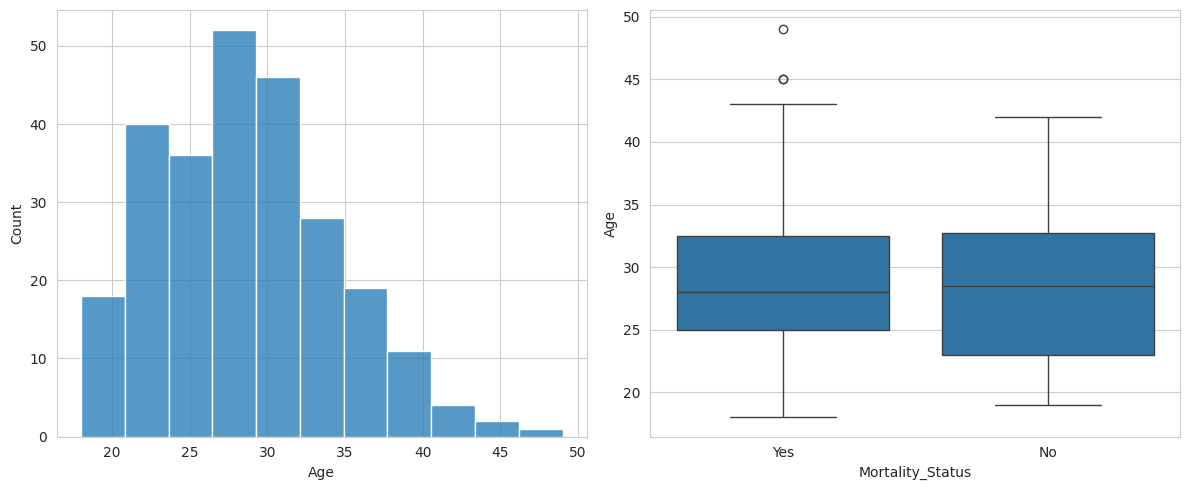

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(data=data, x='Age', ax=ax[0])
sns.boxplot(data=data, x='Mortality_Status', y='Age', ax=ax[1])

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


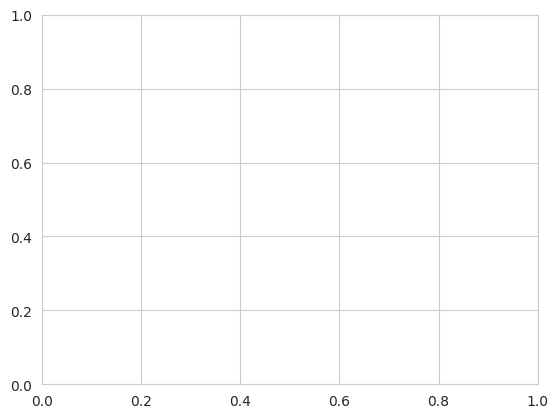

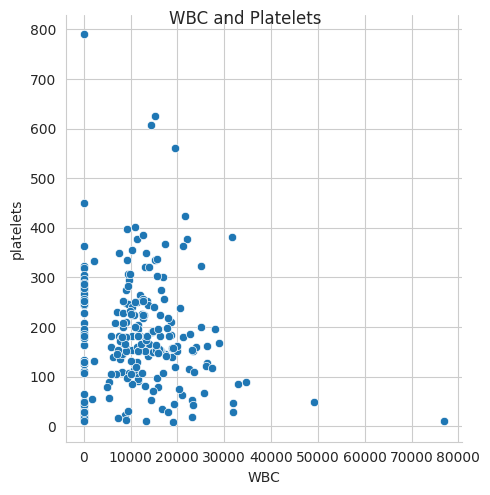

In [13]:
# Relational plot
fig, ax = plt.subplots()
d = sns.relplot(x= 'WBC', y = 'platelets', ax = ax, data = data)
d.figure.suptitle ('WBC and Platelets')
d.set(xlabel = "WBC", ylabel = "platelets")
plt.show()


In [14]:
# Cross tab
import pandas as pd

cross_tab = pd.crosstab(data['Mortality_Status'], data['Emergency_Surgery'])

print(cross_tab)

Emergency_Surgery  No  Yes
Mortality_Status          
No                  4   10
Yes                85  158


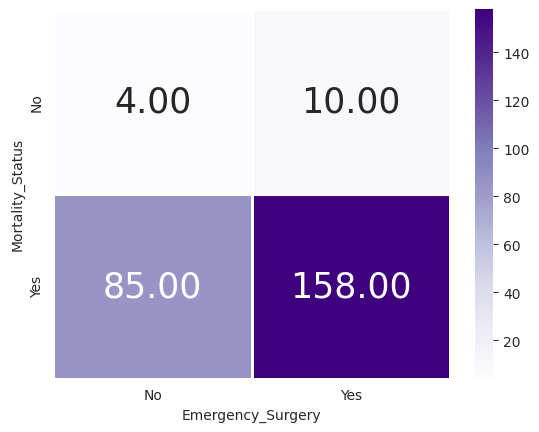

In [15]:
# Heat map
fig, ax = plt.subplots()
sns.heatmap (data = cross_tab, cmap = 'Purples', annot = True, annot_kws = {"size": 25},fmt = ".2f", linewidth = '2', linecolor = "white")
plt.show ()

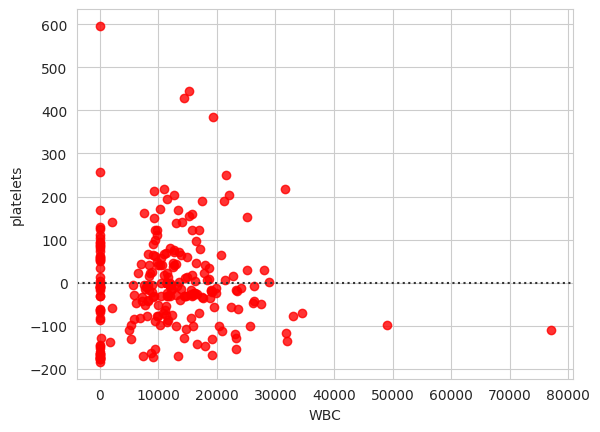

In [16]:
# Residual plot
fig, ax = plt.subplots()
sns.residplot(x = 'WBC', y= 'platelets', data = data, color = "red" )
plt.show()

# Machine Learning  

In [24]:
# Since this data is related to catagorical variable, either we focus on logistic regression or KNN

!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


In [110]:
import pandas as pd
data.sample(5)

,Age,DiabetesYes1,Rheumatological,Respiratorydiseases,Hypertension,Hypothyroidism,Cardiovasculardiseases,cerebrovasculardiseases,Renaldiseases,others_disease,...,PostOperative_Case,Emergency_Surgery,Diagnosis_Disease,Ventilated_Mechanical,Sedation_admission,Cardiovascular_Support,Vasoactiveterapy,Use_antibiotic,Replacement_Renal,Mortality_Status
181,25,No,Yes,No,No,Yes,No,No,No,No,...,Yes,Yes,Elective LSCS,Yes,No,No,No,Yes,No,Yes
148,34,No,No,No,No,No,No,No,No,No,...,Yes,No,Pregnancy-Related Complications (Non-hypertens...,Yes,No,No,No,Yes,No,Yes
88,32,No,No,No,No,No,No,No,No,No,...,No,No,"Hypertensive disorders (Pre-eclampsia, postpar...",Yes,No,No,No,Yes,No,Yes
85,30,No,No,No,No,No,No,No,No,No,...,Yes,Yes,Elective LSCS,Yes,Yes,No,No,Yes,No,Yes
78,26,No,No,No,No,No,No,No,No,No,...,Yes,Yes,Emergency LSCS,No,No,No,No,Yes,No,Yes


In [129]:
# Step 1 — Reload fresh data
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

data = pd.read_excel(r'/content/clean_data_python.xlsx')

# Step 2 — Define columns
nominal_columns = ['Admission_Source', 'Diagnosis_Disease']
numeric_columns = ['Age', 'Fio2', 'Pa02', 'PEEP', 'ArterialPH', 'systolic_blood_pressure',
                   'diastolic_blood_pressure', 'respiratory_rate', 'heart_rate', 'Temperature',
                   'blood_sugar_level', 'hemoglobin', 'platelets', 'WBC', 'Serum_sodium',
                   'serum_potassium', 'serum_bicarbonate', 'serum_creatinine', 'serum_bilirubin', 'blood_urea']
boolean_columns = ['DiabetesYes1', 'Rheumatological', 'Respiratorydiseases', 'Hypertension',
                   'Hypothyroidism', 'Cardiovasculardiseases', 'cerebrovasculardiseases', 'Renaldiseases',
                   'others_disease', 'PostOperative_Case', 'Emergency_Surgery', 'Ventilated_Mechanical',
                   'Sedation_admission', 'Cardiovascular_Support', 'Vasoactiveterapy', 'Use_antibiotic',
                   'Replacement_Renal']

# Step 3 — Map ALL Yes/No columns at once
yes_no_columns = boolean_columns + ['Mortality_Status']
for col in yes_no_columns:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# Verify
print(data[yes_no_columns].isnull().sum())

# Step 4 — Scale numeric
scaler = StandardScaler()
numeric_df_scaled = scaler.fit_transform(data[numeric_columns])

# Step 5 — Encode nominal
nominal_encoders = BinaryEncoder(cols=nominal_columns)
nominal_np = nominal_encoders.fit_transform(data[nominal_columns]).to_numpy()

# Step 6 — Boolean to numpy
bool_np = data[boolean_columns].to_numpy()

# Step 7 — Combine
X = np.concatenate([numeric_df_scaled, nominal_np, bool_np], axis=1)
y = data['Mortality_Status'].to_numpy()

# Step 8 — Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 9 — Train KNN
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)
print("Model trained successfully!")

DiabetesYes1               0
Rheumatological            0
Respiratorydiseases        0
Hypertension               0
Hypothyroidism             0
Cardiovasculardiseases     0
cerebrovasculardiseases    0
Renaldiseases              0
others_disease             0
PostOperative_Case         0
Emergency_Surgery          0
Ventilated_Mechanical      0
Sedation_admission         0
Cardiovascular_Support     0
Vasoactiveterapy           0
Use_antibiotic             0
Replacement_Renal          0
Mortality_Status           0
dtype: int64
Model trained successfully!


In [131]:
# Model Evaluation
from sklearn.metrics import recall_score
y_pred = KNN_model.predict(X_test)
recall_score_val = recall_score(y_pred, y_test)
print(recall_score_val)

0.9423076923076923


In [137]:
# SVM
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Step 1: Load Data
data = pd.read_excel(r'/content/clean_data_python.xlsx')

# ── Step 2: Define Columns
nominal_columns = ['Admission_Source', 'Diagnosis_Disease']
numeric_columns = ['Age', 'Fio2', 'Pa02', 'PEEP', 'ArterialPH', 'systolic_blood_pressure',
                   'diastolic_blood_pressure', 'respiratory_rate', 'heart_rate', 'Temperature',
                   'blood_sugar_level', 'hemoglobin', 'platelets', 'WBC', 'Serum_sodium',
                   'serum_potassium', 'serum_bicarbonate', 'serum_creatinine', 'serum_bilirubin', 'blood_urea']
boolean_columns = ['DiabetesYes1', 'Rheumatological', 'Respiratorydiseases', 'Hypertension',
                   'Hypothyroidism', 'Cardiovasculardiseases', 'cerebrovasculardiseases', 'Renaldiseases',
                   'others_disease', 'PostOperative_Case', 'Emergency_Surgery', 'Ventilated_Mechanical',
                   'Sedation_admission', 'Cardiovascular_Support', 'Vasoactiveterapy', 'Use_antibiotic',
                   'Replacement_Renal']

# ── Step 3: Map Yes/No Columns
yes_no_columns = boolean_columns + ['Mortality_Status']
for col in yes_no_columns:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# Verify
print("Missing values after mapping:")
print(data[yes_no_columns].isnull().sum())

# ── Step 4: Scale Numeric Columns
scaler = StandardScaler()
numeric_df_scaled = scaler.fit_transform(data[numeric_columns])

# ── Step 5: Encode Nominal Columns
nominal_encoders = BinaryEncoder(cols=nominal_columns)
nominal_np = nominal_encoders.fit_transform(data[nominal_columns]).to_numpy()

# ── Step 6: Boolean to Numpy
bool_np = data[boolean_columns].to_numpy()

# ── Step 7: Concatenate Features
X = np.concatenate([numeric_df_scaled, nominal_np, bool_np], axis=1)
y = data['Mortality_Status'].to_numpy()

# ── Step 8: Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ── Step 9: Train SVM Model
SVM_model = SVC(kernel='rbf', random_state=42, class_weight='balanced')
SVM_model.fit(X_train, y_train)
print("\nSVM Model trained successfully!")

# ── Step 10: Evaluate Model
y_pred_svm = SVM_model.predict(X_test)

print("\n=== SVM Recall Score ===")
print(f"Recall : {recall_score(y_test, y_pred_svm):.4f}")

print("\n=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm))




Missing values after mapping:
DiabetesYes1               0
Rheumatological            0
Respiratorydiseases        0
Hypertension               0
Hypothyroidism             0
Cardiovasculardiseases     0
cerebrovasculardiseases    0
Renaldiseases              0
others_disease             0
PostOperative_Case         0
Emergency_Surgery          0
Ventilated_Mechanical      0
Sedation_admission         0
Cardiovascular_Support     0
Vasoactiveterapy           0
Use_antibiotic             0
Replacement_Renal          0
Mortality_Status           0
dtype: int64

SVM Model trained successfully!

=== SVM Recall Score ===
Recall : 1.0000

=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.94      1.00      0.97        49

    accuracy                           0.94        52
   macro avg       0.47      0.50      0.49        52
weighted avg       0.89      0.94      0.91        52

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression Model trained successfully!

=== Logistic Regression Recall Score ===
Recall : 0.9388

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.96      0.94      0.95        49

    accuracy                           0.90        52
   macro avg       0.60      0.64      0.62        52
weighted avg       0.92      0.90      0.91        52



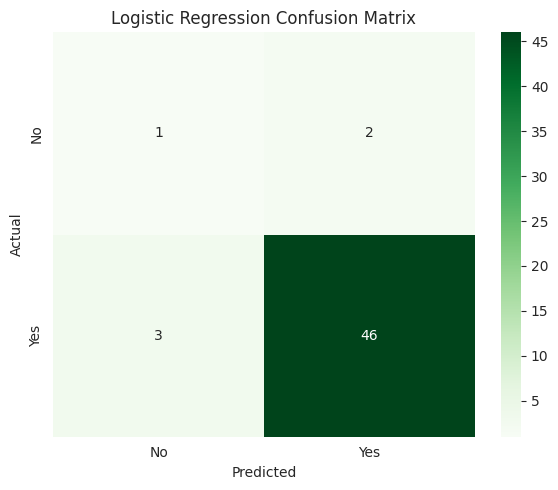

In [138]:
# Logistic Regression
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Step 1: Load Data ─────────────────────────────────────────────────────────
data = pd.read_excel(r'/content/clean_data_python.xlsx')

# ── Step 2: Define Columns ────────────────────────────────────────────────────
nominal_columns = ['Admission_Source', 'Diagnosis_Disease']
numeric_columns = ['Age', 'Fio2', 'Pa02', 'PEEP', 'ArterialPH', 'systolic_blood_pressure',
                   'diastolic_blood_pressure', 'respiratory_rate', 'heart_rate', 'Temperature',
                   'blood_sugar_level', 'hemoglobin', 'platelets', 'WBC', 'Serum_sodium',
                   'serum_potassium', 'serum_bicarbonate', 'serum_creatinine', 'serum_bilirubin', 'blood_urea']
boolean_columns = ['DiabetesYes1', 'Rheumatological', 'Respiratorydiseases', 'Hypertension',
                   'Hypothyroidism', 'Cardiovasculardiseases', 'cerebrovasculardiseases', 'Renaldiseases',
                   'others_disease', 'PostOperative_Case', 'Emergency_Surgery', 'Ventilated_Mechanical',
                   'Sedation_admission', 'Cardiovascular_Support', 'Vasoactiveterapy', 'Use_antibiotic',
                   'Replacement_Renal']

# ── Step 3: Map Yes/No Columns ────────────────────────────────────────────────
yes_no_columns = boolean_columns + ['Mortality_Status']
for col in yes_no_columns:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# ── Step 4: Scale Numeric Columns ─────────────────────────────────────────────
scaler = StandardScaler()
numeric_df_scaled = scaler.fit_transform(data[numeric_columns])

# ── Step 5: Encode Nominal Columns ────────────────────────────────────────────
nominal_encoders = BinaryEncoder(cols=nominal_columns)
nominal_np = nominal_encoders.fit_transform(data[nominal_columns]).to_numpy()

# ── Step 6: Boolean to Numpy ──────────────────────────────────────────────────
bool_np = data[boolean_columns].to_numpy()

# ── Step 7: Concatenate Features ──────────────────────────────────────────────
X = np.concatenate([numeric_df_scaled, nominal_np, bool_np], axis=1)
y = data['Mortality_Status'].to_numpy()

# ── Step 8: Split Data ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Step 9: Train Logistic Regression ─────────────────────────────────────────
LR_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
LR_model.fit(X_train, y_train)
print("Logistic Regression Model trained successfully!")

# ── Step 10: Evaluate Model ───────────────────────────────────────────────────
y_pred_lr = LR_model.predict(X_test)

print("\n=== Logistic Regression Recall Score ===")
print(f"Recall : {recall_score(y_test, y_pred_lr):.4f}")

print("\n=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr))

# ── Step 11: Confusion Matrix ─────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap='Greens', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()



=== Recall Score Comparison ===
KNN Recall                 : 1.0000
SVM Recall                 : 1.0000
Logistic Regression Recall : 0.9388


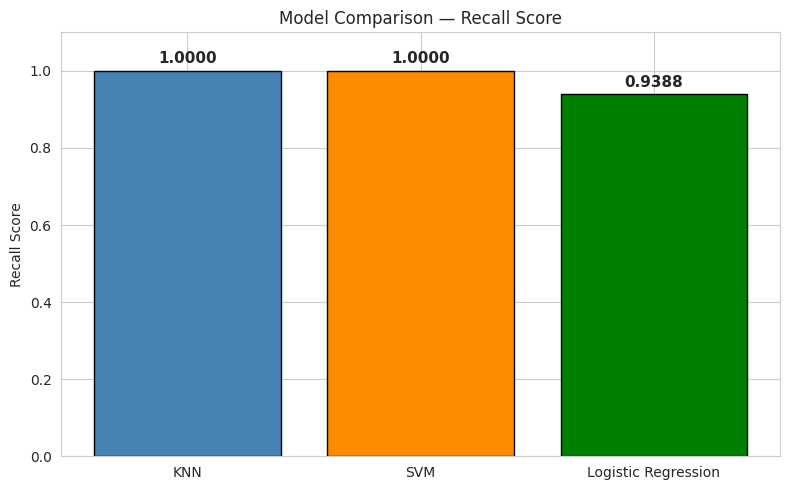

In [140]:
# Model comparison
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)
y_pred_knn = KNN_model.predict(X_test)

SVM_model = SVC(kernel='rbf', random_state=42, class_weight='balanced')
SVM_model.fit(X_train, y_train)
y_pred_svm = SVM_model.predict(X_test)

print("\n=== Recall Score Comparison ===")
print(f"KNN Recall                 : {recall_score(y_test, y_pred_knn):.4f}")
print(f"SVM Recall                 : {recall_score(y_test, y_pred_svm):.4f}")
print(f"Logistic Regression Recall : {recall_score(y_test, y_pred_lr):.4f}")

# ── Step 13: Bar Plot Comparison ──────────────────────────────────────────────
models = ['KNN', 'SVM', 'Logistic Regression']
recalls = [recall_score(y_test, y_pred_knn),
           recall_score(y_test, y_pred_svm),
           recall_score(y_test, y_pred_lr)]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, recalls, color=['steelblue', 'darkorange', 'green'], edgecolor='black')
plt.ylim(0, 1.1)
plt.ylabel('Recall Score')
plt.title('Model Comparison — Recall Score')
for bar, recall in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{recall:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
git init
git add ML.ipynb
git commit -m "Initial commit - ML notebook"

SyntaxError: invalid syntax (2734518859.py, line 1)